<h1 style="text-align: center;">Hotel Booking Cancellation Prediction Using Machine Learning</h1>
<h3 style="text-align: center;">Valencia & Muhammad Rafi Andrianto</h3>

---

## **Section 0. Setup**

### **0.1 Import Library**

In [1]:
# common library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Feature Engineering
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from category_encoders import BinaryEncoder
from feature_engine.outliers import Winsorizer, OutlierTrimmer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split
from feature_engine.selection import DropFeatures
from feature_engine.datetime import DatetimeFeatures

# Model and pipelining
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import cross_validate
from sklearn.model_selection import RandomizedSearchCV

# Imbalance
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

### **0.2 Global Configuration**

In [2]:
RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

## **Section 1. Business Understanding**

**Background**

Hotel booking cancellations create uncertainty in occupancy planning and reduce potential revenue. This project analyzes hotel booking data from a hotel in Portugal to develop a machine learning model that predicts whether a customer will cancel their reservation. Early identification of booking cancellations enables hotels to reduce revenue loss, optimize room occupancy, and improve operational planning.

**Key Stakeholders**
- Hotel General Manager: responsible for hotel performance and business strategy.
- Revenue Management Team: responsible for hotel pricing, occupancy, and revenue.
- Front Office Team: responsible for room reservations, booking policies and coordinating guest arrivals and room allocation.
- Data Science Team: provides analytical insights and builds predictive tools to support business decisions.

**Problem Statement**

Hotel booking cancellations represent a significant operational and financial challenge for the hotel. With a substantial number of reservations being canceled before check-in, the hotel faces:
- **Revenue loss** from rooms that remain vacant because canceled bookings cannot always be replaced in time.
- **Operational challenges** in managing room allocation and staff planning..
- **Difficulty managing room availability and pricing**, reducing opportunities to maximize occupancy and revenue.
- **Difficulty forecasting future bookings**, making it harder to plan hotel operations and promotions.

Without accurately identifying customers who are likely to cancel, the hotel cannot proactively implement strategies such as deposit requirements, personalized reminders, or targeted retention offers to minimize cancellations and improve occupancy rates.

**Goals**

To address this challenge, the hotel aims to:
- **Analyze cancellation patterns**: Identify the booking characteristics and customer behaviors that are most associated with booking cancellations.
- **Build a predictive machine learning model**: Develop and evaluate a model that can identify customers who are likely to cancel their reservations before check-in.
- **Support proactive decision-makin**g: Enable hotel teams to take preventive actions, such as sending booking reminders, requiring deposits, or offering personalized incentives to reduce cancellations and improve room occupancy.

**Metric Evaluations**

**Type I Error (False Positive)**
- Prediction: The booking will be canceled.
- Actual: The booking is **not** canceled.

Consequence:

The hotel takes unnecessary actions, such as sending additional reminders, requesting a deposit, or offering incentives.
This increases operational costs and may negatively affect the customer experience.

**Type II Error (False Negative)**
- Prediction: The booking will not be canceled.
- Actual: The booking is canceled.

Consequence:

The hotel misses the opportunity to take preventive actions.
The room may remain vacant, resulting in lower occupancy and lost revenue.

---
## **Section 2. Data Understanding**
This section provides an overview of the dataset's structure, including its size and format, before performing data cleaning.

### **2.1 General Information**

In [3]:
# Load Dataset
df = pd.read_csv('../data/raw/data_hotel_booking_demand.csv')
df.head()

,country,market_segment,previous_cancellations,booking_changes,deposit_type,days_in_waiting_list,customer_type,reserved_room_type,required_car_parking_spaces,total_of_special_requests,is_canceled
0,IRL,Offline TA/TO,0,0,No Deposit,0,Transient-Party,A,0,0,0
1,FRA,Online TA,0,0,No Deposit,0,Transient,A,0,2,0
2,PRT,Online TA,0,1,No Deposit,0,Transient,A,0,2,0
3,NLD,Online TA,0,0,No Deposit,0,Transient,A,0,1,1
4,PRT,Online TA,0,2,No Deposit,0,Transient,A,0,2,0


In [4]:
# Dataset Dimension
print(f"Dataset Dimension: {df.shape}")

Dataset Dimension: (83573, 11)


In [5]:
# Count and Datatype for each Column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83573 entries, 0 to 83572
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   country                      83222 non-null  str  
 1   market_segment               83573 non-null  str  
 2   previous_cancellations       83573 non-null  int64
 3   booking_changes              83573 non-null  int64
 4   deposit_type                 83573 non-null  str  
 5   days_in_waiting_list         83573 non-null  int64
 6   customer_type                83573 non-null  str  
 7   reserved_room_type           83573 non-null  str  
 8   required_car_parking_spaces  83573 non-null  int64
 9   total_of_special_requests    83573 non-null  int64
 10  is_canceled                  83573 non-null  int64
dtypes: int64(6), str(5)
memory usage: 9.7 MB


### **2.2 Feature Information**

**Features Identification**

| Column | Type | Description |
| --- | --- | --- |
| country |string| Country of origin.|
| market_segment|string|Market segment designation. |
| previous_cancellations|integer| Number of previous bookings that were cancelled by the customer prior to the current booking|
| booking_changes|integer| Number of changes/amendments made to the booking from the moment the booking was entered on the PMS until the moment of check-in or cancellation|
| deposit_type|string| Indication on if the customer made a deposit to guarantee the booking.|
| days_in_waiting_list|integer| Number of days the booking was in the waiting list before it was confirmed to the customer|
| customer_type|string| Type of booking|
| reserved_room_type|string| Code of room type reserved. Code is presented instead of designation for anonymity reasons|
| required_car_parking_space|integer| Number of car parking spaces required by the customer|
| total_of_special_request|integer| Number of special requests made by the customer (e.g. twin bed or high floor)|
| is_canceled|integer| Value indicating if the booking was canceled (1) or not (0)|


### **2.3 Statistics Summary**

#### **2.3.1 Descriptive Statistics of Numerical Features**

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
previous_cancellations,83573.0,0.086798,0.841011,0.0,0.0,0.0,0.0,26.0
booking_changes,83573.0,0.220897,0.648635,0.0,0.0,0.0,0.0,21.0
days_in_waiting_list,83573.0,2.330561,17.673051,0.0,0.0,0.0,0.0,391.0
required_car_parking_spaces,83573.0,0.062999,0.246919,0.0,0.0,0.0,0.0,8.0
total_of_special_requests,83573.0,0.573211,0.795163,0.0,0.0,0.0,1.0,5.0
is_canceled,83573.0,0.368277,0.482340,0.0,0.0,0.0,1.0,1.0


#### **2.3.2 Descriptive Statistics of Categorical Features**

In [8]:
df.describe(include='object').T

/var/folders/f7/c5qn45190zdds3jh0t1vyfmh0000gn/T/ipykernel_8484/1760094569.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
country,83222,162,PRT,34097
market_segment,83573,8,Online TA,39460
deposit_type,83573,3,No Deposit,73352
customer_type,83573,4,Transient,62732
reserved_room_type,83573,10,A,60041


## **Section 3. Data Cleaning**

### **3.1 Missing Values**
Identify columns with missing values and determine the appropriate handling strategy, such as dropping, imputing, or retaining them based on business and analytical considerations.

In [9]:
# check missing value
df.isnull().sum()

country                        351
market_segment                   0
previous_cancellations           0
booking_changes                  0
deposit_type                     0
days_in_waiting_list             0
customer_type                    0
reserved_room_type               0
required_car_parking_spaces      0
total_of_special_requests        0
is_canceled                      0
dtype: int64

> The `country` column contains 351 missing values. We can either drop them or label them as 'uknown', but for now we will drop them.

In [10]:
# Drop
df.dropna(subset=['country'], inplace=True)
df.isnull().sum()

country                        0
market_segment                 0
previous_cancellations         0
booking_changes                0
deposit_type                   0
days_in_waiting_list           0
customer_type                  0
reserved_room_type             0
required_car_parking_spaces    0
total_of_special_requests      0
is_canceled                    0
dtype: int64

### **3.2 Duplicated Values**

In [11]:
# check duplicated values
# Identify fully duplicated records across all columns

total_duplicates = df.duplicated().sum()
percentage_duplicates = (total_duplicates / len(df)) * 100

print(total_duplicates)
print(f"Percentage: {percentage_duplicates:.2f}%")

73138
Percentage: 87.88%


> No duplicates were removed because the dataset has no unique transaction ID.

### **3.3 Data Consistency Check**
- Check for spelling errors or typos in categorical values.
- Check for inconsistent capitalization and formatting.
- Check for leading, trailing, or hidden whitespace characters.

In [12]:
# Remove hidden whitespace from the beginning/end of strings (if any) and standardize text casing
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

/var/folders/f7/c5qn45190zdds3jh0t1vyfmh0000gn/T/ipykernel_8484/200614727.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


### **3.4 Identify Anomaly Values**
In this section, we inspect our categorical and numerical features for statistical anomalies, high cardinality, rare categories, and extreme numerical outliers. Managing these anomalies is crucial for preventing overfitting and ensuring our models generalize well.

#### 3.4.1 Categorical Features
Checking the cardinality (number of unique values) and look for categories with extremely low frequency. If a categorical feature has too many unique values or contains categories with extremely low frequencies (<0.1% of the dataset), it can lead to overfitting or inefficiency during encoding.

In [13]:
# Check unique values and distribution of categorical features
categorical_features = ['country', 'market_segment', 'deposit_type', 'customer_type', 'reserved_room_type']

# Threshold
threshold_pct = 0.1

for i in categorical_features:
    print(f"\n--- Column: {i} ---")
    print(f"Total Unique: {df[i].nunique(dropna=False)}")
    print("Distribution:")

    counts = df[i].value_counts(dropna=False)
    pcts = df[i].value_counts(dropna=False, normalize=True) * 100

    for idx, (val, count, pct) in enumerate(zip(counts.index, counts.values, pcts.values)):
        flag = " [LOW]" if pct < threshold_pct else ""
        print(f" {idx+1}. {val}: {count} ({pct:.3f}%){flag}")



--- Column: country ---
Total Unique: 162
Distribution:
 1. PRT: 34097 (40.971%)
 2. GBR: 8495 (10.208%)
 3. FRA: 7307 (8.780%)
 4. ESP: 5996 (7.205%)
 5. DEU: 5116 (6.147%)
 6. ITA: 2658 (3.194%)
 7. IRL: 2340 (2.812%)
 8. BEL: 1648 (1.980%)
 9. BRA: 1553 (1.866%)
 10. USA: 1472 (1.769%)
 11. NLD: 1433 (1.722%)
 12. CHE: 1201 (1.443%)
 13. CN: 886 (1.065%)
 14. AUT: 873 (1.049%)
 15. SWE: 724 (0.870%)
 16. CHN: 709 (0.852%)
 17. POL: 638 (0.767%)
 18. ISR: 463 (0.556%)
 19. RUS: 435 (0.523%)
 20. NOR: 431 (0.518%)
 21. ROU: 341 (0.410%)
 22. FIN: 316 (0.380%)
 23. DNK: 308 (0.370%)
 24. AUS: 301 (0.362%)
 25. AGO: 243 (0.292%)
 26. LUX: 181 (0.217%)
 27. MAR: 179 (0.215%)
 28. TUR: 163 (0.196%)
 29. ARG: 154 (0.185%)
 30. HUN: 138 (0.166%)
 31. JPN: 129 (0.155%)
 32. CZE: 117 (0.141%)
 33. IND: 104 (0.125%)
 34. KOR: 102 (0.123%)
 35. GRC: 94 (0.113%)
 36. SRB: 81 (0.097%) [LOW]
 37. DZA: 80 (0.096%) [LOW]
 38. HRV: 73 (0.088%) [LOW]
 39. IRN: 63 (0.076%) [LOW]
 40. ZAF: 60 (0.072%) 


| Feature | Identified Anomaly / Rare Category | Decision | Business & Technical Justification |
| :--- | :--- | :--- | :--- |
|  `country` | 127 countries have a frequency $< 0.1\%$ (from SRB to AIA). | Keep | Dropping the column would lose valuable geographic signals (domestic vs. international customer behaviors). However, keeping 162 unique categories would cause the very huge dimensionality during one-hot encoding. *(maybe during feature engineering, we will group all countries with a frequency $< 1\%$ into a single 'Other' category. so we do binning (?))* |
| `market_segment` | 'Undefined' has only 1 occurrence ($0.001\%$). | Drop | A single instance represents noise or a data entry error. It holds no predictive power and can introduce zero-variance issues in dummy variables. We will drop this single row. |
| `deposit_type` | None (Lowest is 'Refundable' at $0.132\%$, which is above our $0.1\%$ threshold). | Keep | The category distributions are healthy and reflect actual financial terms of bookings. |
| `customer_type` | None (Lowest is 'Group' at $0.503\%$). | Keep | No anomalies detected; all values represent distinct and valid customer profiles. |
| `reserved_room_type` | 'L' (3 rows, $0.004\%$) and 'P' (2 rows, $0.002\%$) are extremely rare. | Keep / Group (maybe idk) | Dropping the column is not an option as room type dictates pricing and preference. |


In [14]:
# Filtering 1 'Undefined' value on the column market_segment
display(df[df['market_segment'] == 'Undefined'])

print(f"Rows Before: {len(df)}")
df = df[df['market_segment'] != 'Undefined']
print(f"Rows After: {len(df)}")

,country,market_segment,previous_cancellations,booking_changes,deposit_type,days_in_waiting_list,customer_type,reserved_room_type,required_car_parking_spaces,total_of_special_requests,is_canceled
70217,PRT,Undefined,0,0,No Deposit,0,Transient-Party,B,0,1,1


Rows Before: 83222
Rows After: 83221


#### 3.4.1 Numerical Features
Checking the distributions, skewness, and extreme outliers. For Numericals, we check for extreme outliers using both visual boxplots and quantitative descriptive statistics.

In [15]:
# Check unique values and distribution of numerical features
numerical_features = ['previous_cancellations', 'booking_changes', 'days_in_waiting_list', 'required_car_parking_spaces', 'total_of_special_requests']

for col in numerical_features:
    print(f"\n--- Column: {col} ---")
    print(f"Total Unique: {df[col].nunique(dropna=False)}")
    print("Distribusion:")
    
    counts = df[col].value_counts(dropna=False)
    
    for idx, (val, count) in enumerate(zip(counts.index, counts.values)):
        print(f" {idx+1}. Value {val}: {count} ")


--- Column: previous_cancellations ---
Total Unique: 15
Distribusion:
 1. Value 0: 78731 
 2. Value 1: 4186 
 3. Value 2: 84 
 4. Value 3: 46 
 5. Value 24: 33 
 6. Value 11: 28 
 7. Value 6: 19 
 8. Value 4: 19 
 9. Value 26: 18 
 10. Value 25: 17 
 11. Value 19: 12 
 12. Value 13: 10 
 13. Value 14: 10 
 14. Value 5: 7 
 15. Value 21: 1 

--- Column: booking_changes ---
Total Unique: 19
Distribusion:
 1. Value 0: 70575 
 2. Value 1: 8926 
 3. Value 2: 2638 
 4. Value 3: 637 
 5. Value 4: 259 
 6. Value 5: 90 
 7. Value 6: 39 
 8. Value 7: 23 
 9. Value 8: 10 
 10. Value 10: 5 
 11. Value 9: 4 
 12. Value 13: 4 
 13. Value 17: 2 
 14. Value 12: 2 
 15. Value 14: 2 
 16. Value 16: 2 
 17. Value 21: 1 
 18. Value 20: 1 
 19. Value 15: 1 

--- Column: days_in_waiting_list ---
Total Unique: 115
Distribusion:
 1. Value 0: 80636 
 2. Value 39: 166 
 3. Value 58: 104 
 4. Value 31: 93 
 5. Value 44: 93 
 6. Value 46: 66 
 7. Value 35: 66 
 8. Value 87: 61 
 9. Value 69: 60 
 10. Value 63: 5

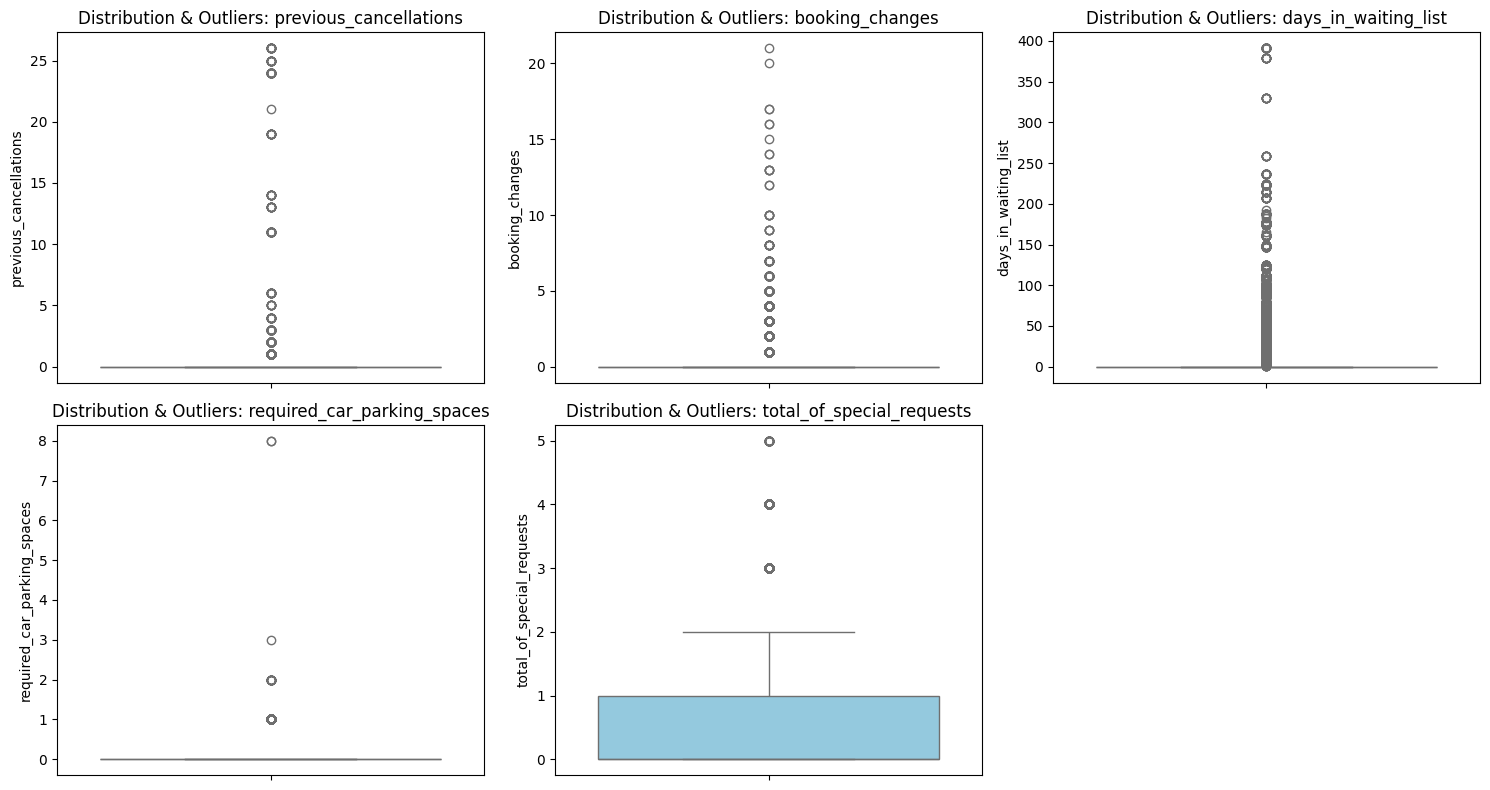

In [19]:
# Visualizing outliers
plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, y=col, color='skyblue')
    plt.title(f'Distribution & Outliers: {col}')
plt.tight_layout()
plt.show()


In [ ]:
# Check skewness to check distribution shapes
for col in numerical_features:
    print(f"'{col}' Skewness = {df[col].skew():.2f}")

'previous_cancellations' Skewness = 24.37
'booking_changes' Skewness = 6.01
'days_in_waiting_list' Skewness = 11.86
'required_car_parking_spaces' Skewness = 4.36
'total_of_special_requests' Skewness = 1.35


All of the numerical features have positive skewness:
1. `previous_cancellations` (Skewness = 24.37): This is extremely highly right-skewed. Almost everyone has $0$ cancellations, but a tiny group of people have up to $26$ cancellations, dragging the distribution's tail incredibly far to the right.

2. `booking_changes` (Skewness = 6.01) & `required_car_parking_spaces` (Skewness = 4.36): Similarly right-skewed because most values are $0$

3. `days_in_waiting_list` (Skewness = 11.86): Heavily right-skewed due to a few bookings waiting for hundreds of days.

4. `total_of_special_requests` (Skewness = 1.35): Moderately right-skewed but forms a standard distribution.

| Feature | Action Decision | Business & Technical Justification |
| :--- | :--- | :--- |
| `previous_cancellations` | Keep | While the presence of extreme values (customers with 24 or 26 previous cancellations) makes this feature highly right-skewed, these are not data entry errors. A customer who has canceled dozens of times in the past is highly likely to cancel again. Removing these outliers would destroy a highly predictive feature for our cancellation model. |
| `booking_changes` | Keep | Most customers do not change their bookings once made. However, values like 15 or 21 changes, while rare, represent authentic customer updates (often associated with group bookings or corporate changes). |
| `days_in_waiting_list` | Keep | The majority of bookings are confirmed immediately. Long waiting times (such as 391 days) are still plausible and valid operational realities during peak seasons or high-demand events. |
| `required_car_parking_spaces` | Keep | The maximum value of 8 requested spots is highly unusual but completely realistic for large families or groups traveling together. Since there are no anomaly values (like negative parking spots), we keep the original values. |
| `total_of_special_requests` | Keep | This feature have a valid distribution with no anomaly values. |


## **Section 4. Exploratory Data Analysis (EDA)**

### **4.1 Univariate Analysis**
Here, we analyze single variables in isolation. It allows us to capture the distribution shape, central tendencies (like mean or mode), frequency of categories, and potential class imbalances without any external noise from other variables.


#### **Categorical**

#### **4.1.1 Distribution of Target Variable (`is_canceled`)**

In [32]:
# Check target proportion
target_counts = df['is_canceled'].value_counts()

for val, count in zip(target_counts.index, target_counts.values):
    status = "Cancel" if val == 1 else "Not Canceled"
    print(f"[Class {val}] {status}: {count} ")

[Class 0] Not Canceled: 52490 
[Class 1] Cancel: 30731 


/var/folders/f7/c5qn45190zdds3jh0t1vyfmh0000gn/T/ipykernel_8484/656197564.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index, y=target_counts.values, palette=['#2b5c8f', '#d95f02'])


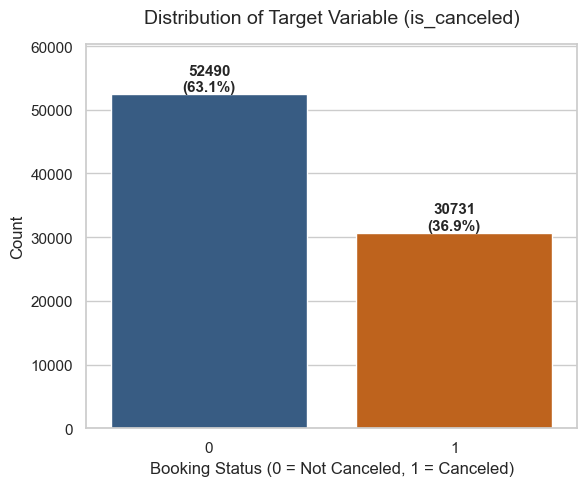

In [29]:
plt.figure(figsize=(6, 5))
sns.barplot(x=target_counts.index, y=target_counts.values, palette=['#2b5c8f', '#d95f02'])

plt.title("Distribution of Target Variable (is_canceled)", pad=15)
plt.xlabel("Booking Status (0 = Not Canceled, 1 = Canceled)")
plt.ylabel("Count")

plt.ylim(0, max(target_counts.values) * 1.15)

# Add percentage and count labels on top of the bars
for idx, val in enumerate(target_counts.values):
    pct = (val / len(df)) * 100
    plt.text(idx, val, f"{val}\n({pct:.1f}%)", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


* No severe class imbalance. Since the minority class (`is_canceled` = 1) makes up **36.9%** of the data, the dataset is relatively well-balanced. We do not need to implement complex synthetic sampling methods (like SMOTE)

* While the data is balanced enough for standard training, relying purely on Accuracy can still be deceptive. To ensure we capture cancellations accurately without hurting hotel revenue with false alarms, we will evaluate our models using **Precision**, **Recall**, and the **F1-Score**.

#### **4.1.2 Distribution of `market_segment`**

/var/folders/f7/c5qn45190zdds3jh0t1vyfmh0000gn/T/ipykernel_8484/3631381738.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='market_segment', order=order, palette='Blues_r')


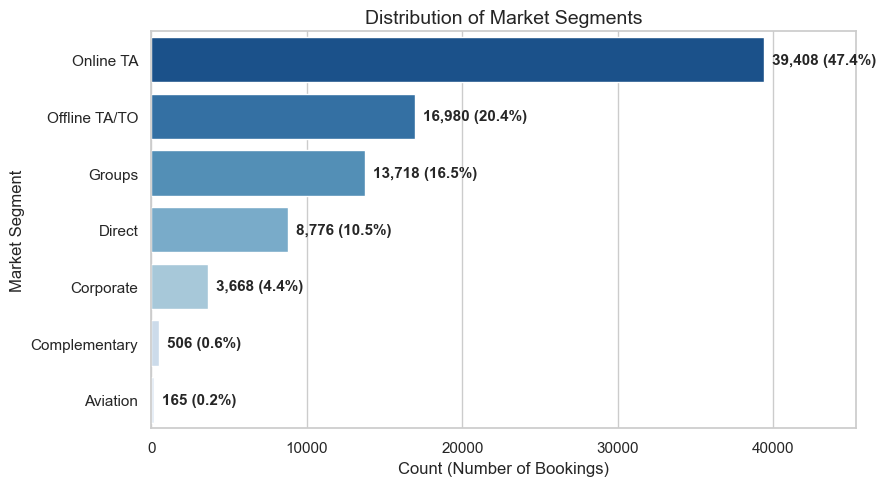

In [35]:
plt.figure(figsize=(9, 5))

order = df['market_segment'].value_counts().index
sns.countplot(data=df, y='market_segment', order=order, palette='Blues_r')

plt.title("Distribution of Market Segments")
plt.xlabel("Count (Number of Bookings)")
plt.ylabel("Market Segment")

# Adding values and percentage labels on the horizontal bars
total = len(df)
for i, col_name in enumerate(order):
    count = df['market_segment'].value_counts()[col_name]
    pct = (count / total) * 100
    plt.text(count + 500, i, f"{count:,} ({pct:.1f}%)", va='center', fontweight='bold')

plt.xlim(0, df['market_segment'].value_counts().max() * 1.15) # Add padding space for labels
plt.tight_layout()
plt.show()

* Almost half of our business (47.4%) comes through Online Travel Agencies.

* 

#### **4.1.3 Distribution of `deposit_type`**

/var/folders/f7/c5qn45190zdds3jh0t1vyfmh0000gn/T/ipykernel_8484/2472058255.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='deposit_type', order=order, palette='Greens_r')


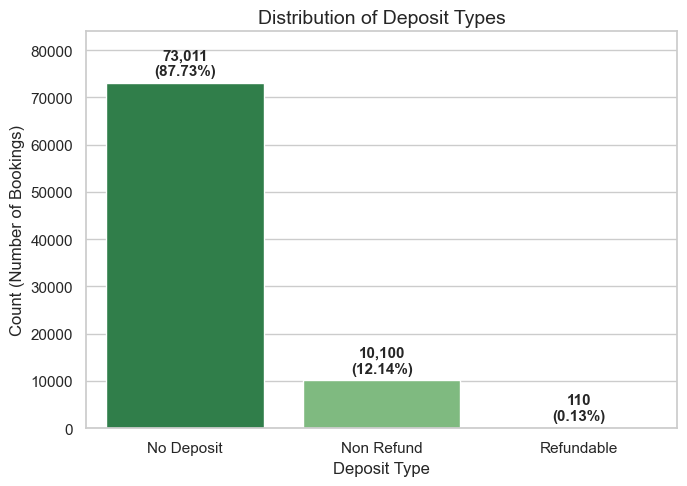

In [36]:
plt.figure(figsize=(7, 5))

order = df['deposit_type'].value_counts().index
sns.countplot(data=df, x='deposit_type', order=order, palette='Greens_r')

plt.title("Distribution of Deposit Types")
plt.xlabel("Deposit Type")
plt.ylabel("Count (Number of Bookings)")

# Adding values and percentage labels on top of the bars
total = len(df)
for i, col_name in enumerate(order):
    count = df['deposit_type'].value_counts()[col_name]
    pct = (count / total) * 100
    plt.text(i, count + 1000, f"{count:,}\n({pct:.2f}%)", ha='center', va='bottom', fontweight='bold')

plt.ylim(0, df['deposit_type'].value_counts().max() * 1.15) # Add padding space for labels
plt.tight_layout()
plt.show()

* **87.73%** of bookings are made under a 'No Deposit' policy. This indicates that the vast majority of customers bear absolutely zero immediate financial risk if they cancel their booking. Since there are no consequences, this likely serves as a primary driver for the hotel's high cancellation rates.

* Theoretically, 'Non Refund' bookings should exhibit extremely low cancellation rates because guests lose their money. However, in our upcoming bivariate analysis, we must verify if this holds true.

#### **4.1.4 Distribution of `customer_type`**

/var/folders/f7/c5qn45190zdds3jh0t1vyfmh0000gn/T/ipykernel_8484/3031918516.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='customer_type', order=order, palette='Purples_r')


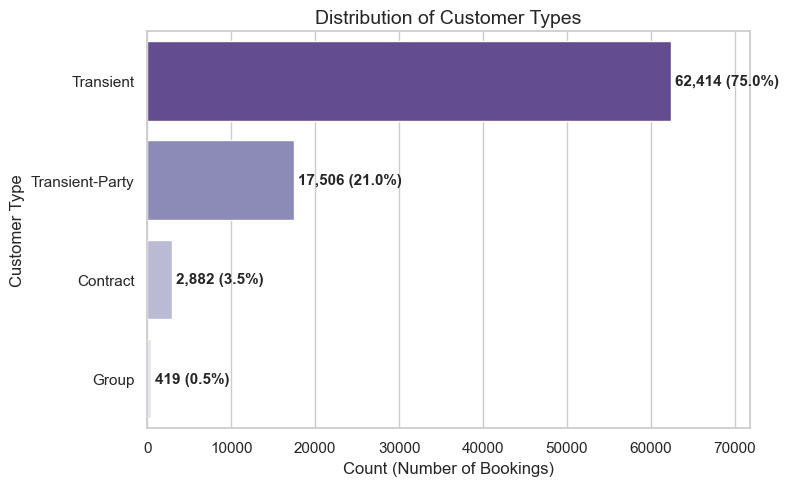

In [37]:
plt.figure(figsize=(8, 5))

order = df['customer_type'].value_counts().index
sns.countplot(data=df, y='customer_type', order=order, palette='Purples_r')

plt.title("Distribution of Customer Types")
plt.xlabel("Count (Number of Bookings)")
plt.ylabel("Customer Type")

# Adding values and percentage labels on the horizontal bars
total = len(df)
for i, col_name in enumerate(order):
    count = df['customer_type'].value_counts()[col_name]
    pct = (count / total) * 100
    plt.text(count + 500, i, f"{count:,} ({pct:.1f}%)", va='center', fontweight='bold')

plt.xlim(0, df['customer_type'].value_counts().max() * 1.15) 
plt.tight_layout()
plt.show()

* **75.0%** of the bookings belong to 'Transient' customers (walk ins, independent online bookings, or standalone reservations). These customers typically display more volatile, price sensitive behavior and lack corporate accountability, making them prime candidates for sudden adjustments or cancellations.

* **21.0%** of 'Transient-Party'. These are independent bookings but linked to another reservation (like families booking multiple rooms under separate individual names). They represent an important secondary block that might exhibit correlated cancellation behaviors (if one room in the party cancels, the others might follow).

#### **4.1.5 Distribution of `reserved_room_type`**

/var/folders/f7/c5qn45190zdds3jh0t1vyfmh0000gn/T/ipykernel_8484/2104926312.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='reserved_room_type', order=order, palette='Reds_r')


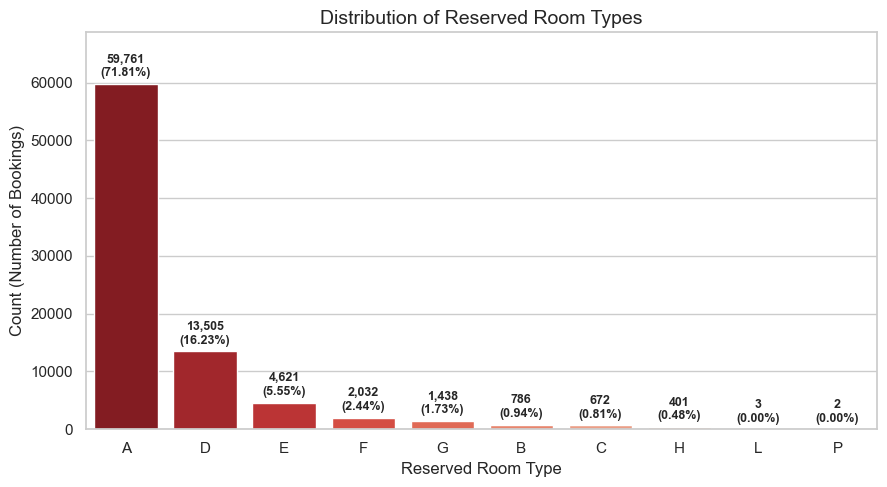

In [38]:
plt.figure(figsize=(9, 5))

order = df['reserved_room_type'].value_counts().index
sns.countplot(data=df, x='reserved_room_type', order=order, palette='Reds_r')

plt.title("Distribution of Reserved Room Types")
plt.xlabel("Reserved Room Type")
plt.ylabel("Count (Number of Bookings)")

# Adding values and percentage labels on top of the bars
total = len(df)
for i, col_name in enumerate(order):
    count = df['reserved_room_type'].value_counts()[col_name]
    pct = (count / total) * 100
    plt.text(i, count + 800, f"{count:,}\n({pct:.2f}%)", ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.ylim(0, df['reserved_room_type'].value_counts().max() * 1.15) 
plt.tight_layout()
plt.show()

* Room Type A have the most values at **71.84%**. This suggests it maybe (?) represents the standard room inventory configuration.

* The visual drop-off confirms our clean-up choice in Section 3.4. Very rare inventory categories like 'P' and 'L' are virtually invisible on the scale. Grouping them downstream protects the model from tracking sparse, noisy signals.

* Standard rooms (?) (Type A) often attract more price conscious travelers or standard business stays, which may have higher churn volatility. On the other hand, premium suites (like F or G maybe (?)) are usually tied to higher tier price points or special events, which might show different commitment behaviors.

#### **Numerical**

#### **4.1.6 Distribution of `total_of_special_requests`**

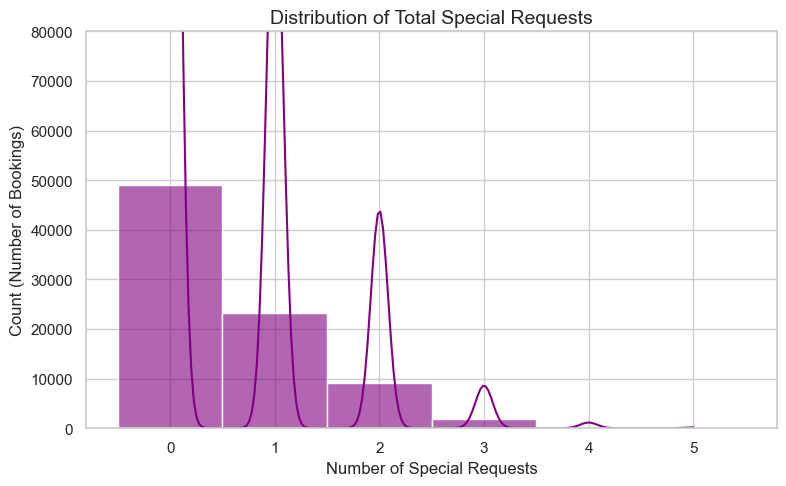

In [44]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='total_of_special_requests', kde=True, discrete=True, color='purple', alpha=0.6)

plt.title("Distribution of Total Special Requests")
plt.xlabel("Number of Special Requests")
plt.ylabel("Count (Number of Bookings)")
plt.ylim(0, 80000)

plt.tight_layout()
plt.show()

* More than half of all guests make zero special requests. From a behavioral standpoint, making special requests reflects a higher engagement which means a customer taking the time to detail their preferences is likely more committed to the stay.

#### **4.1.7 Distribution of `booking_changes`**

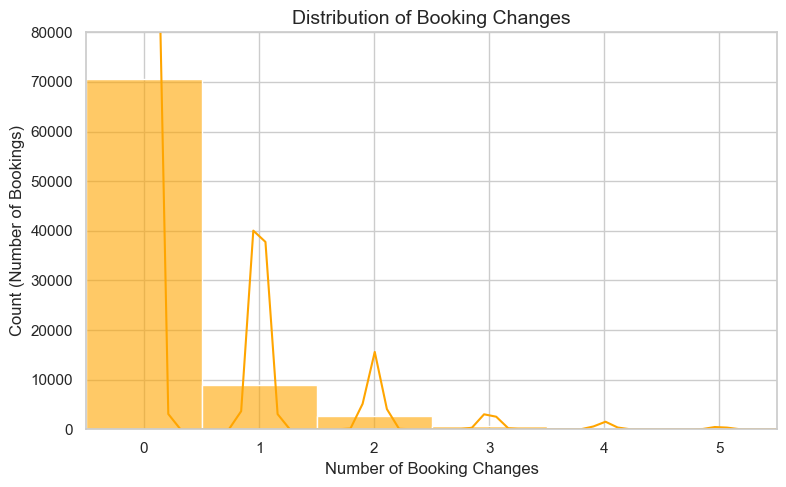

In [45]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='booking_changes', kde=True, discrete=True, color='orange', alpha=0.6)

plt.title("Distribution of Booking Changes")
plt.xlabel("Number of Booking Changes")
plt.ylabel("Count (Number of Bookings)")
plt.xlim(-0.5, 5.5)
plt.ylim(0, 80000)
plt.tight_layout()
plt.show()

* **84.80%** of reservations are never modified after creation. The majority of customers likely have a 'book and relax' approach to booking hotel accommodations.

* When a customer triggers a booking modification, it suggests they are actively customizing their stay (in a scenario where they have a change of plans in their travels).

#### **4.1.8 Distribution of `days_in_waiting_list`**

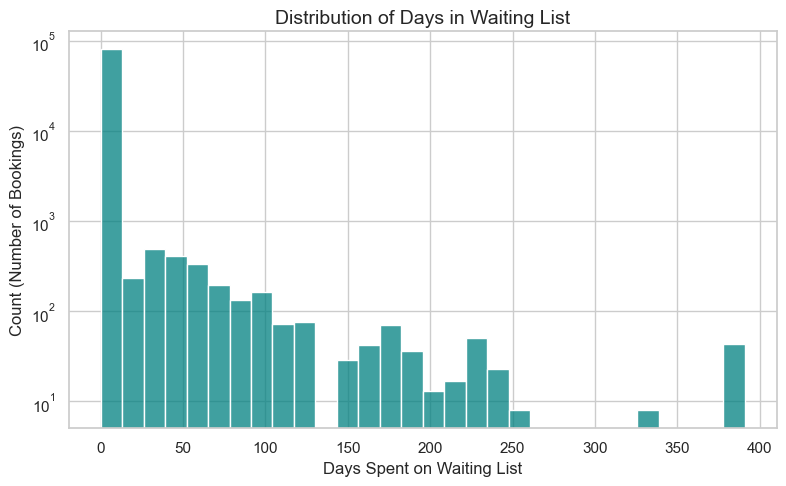

In [54]:
plt.figure(figsize=(8, 5))
# Using a slightly larger bin width because the values range up to several hundred days
sns.histplot(data=df, x='days_in_waiting_list', bins=30, color='teal')

plt.title("Distribution of Days in Waiting List")
plt.xlabel("Days Spent on Waiting List")
plt.ylabel("Count (Number of Bookings)")
plt.yscale('log') # Using a log scale helps visualize the long tail since 0 dominates completely
plt.tight_layout()
plt.show()

* A non-zero value in this column indicates an overcapacity or extreme demand periods (such as peak seasonal events or massive corporate conventions)

* A long wait time can make a customer look for another hotel.

#### **4.1.9 Distribution of `required_car_parking_spaces`**

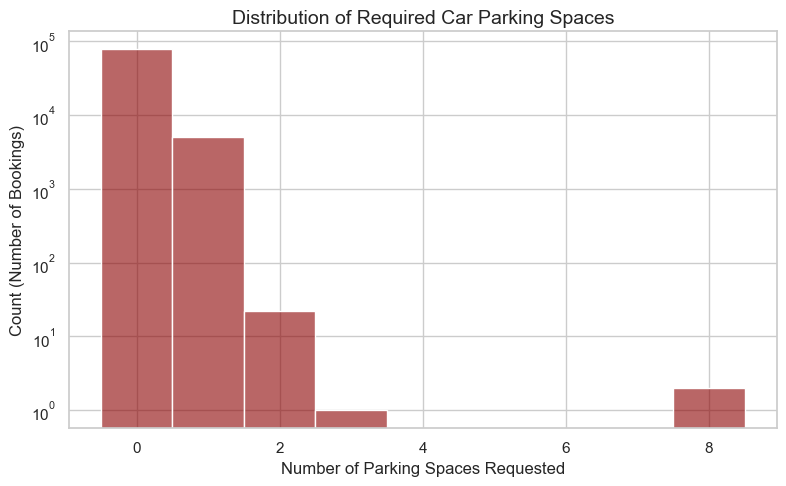

In [56]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='required_car_parking_spaces', kde=False, discrete=True, color='darkred', alpha=0.6)

plt.title("Distribution of Required Car Parking Spaces")
plt.xlabel("Number of Parking Spaces Requested")
plt.ylabel("Count (Number of Bookings)")
plt.yscale('log') # Log scale applied due to extreme zero-inflation
plt.tight_layout()
plt.show()

* Customers who requests a parking space are usually driving their own or a rental car to the hotel. Because they already have a well planned travel, they are highly committed and very unlikely to cancel their booking

* 

### **4.2 Bivariate Analysis**

#### **4.2.1 Categorical**

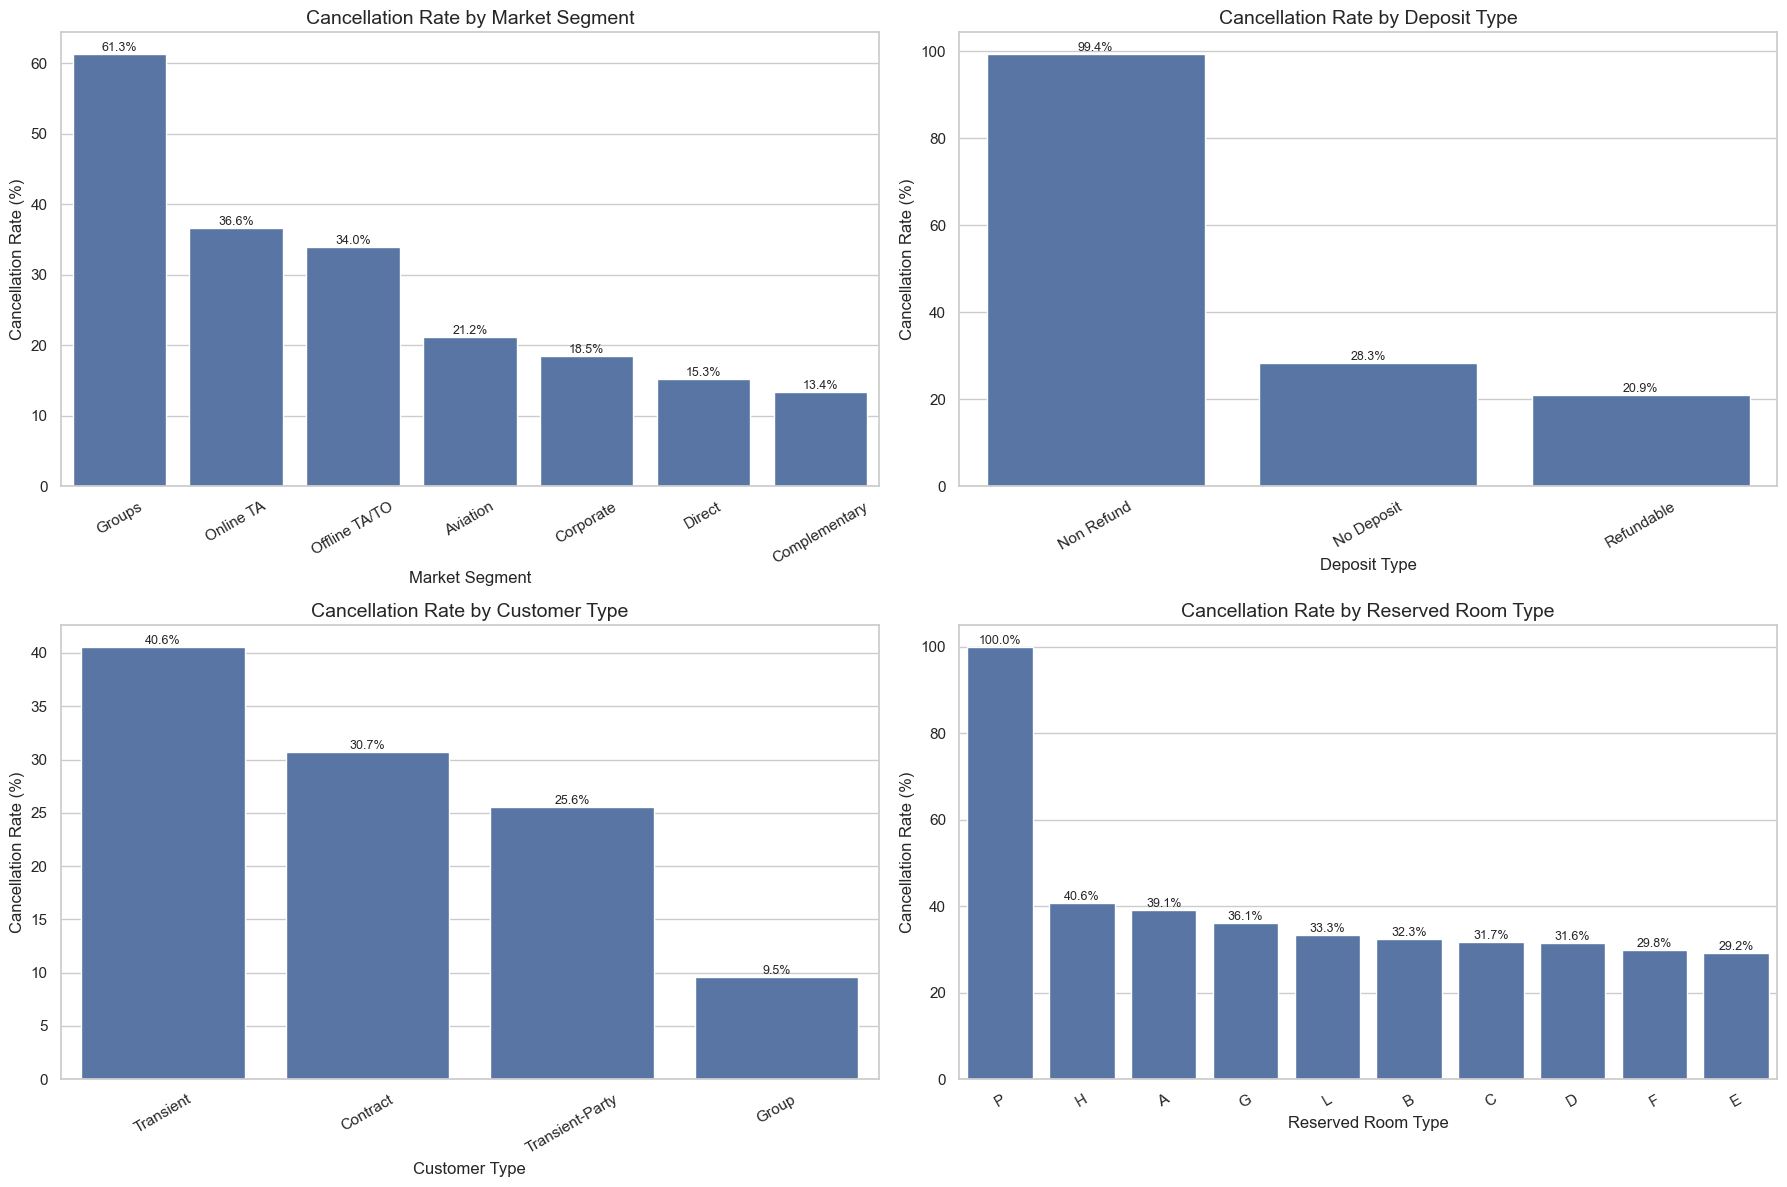

In [57]:
cat_features = [
    'market_segment',
    'deposit_type',
    'customer_type',
    'reserved_room_type'
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_features):

    cancel_rate = (
        df.groupby(col)['is_canceled']
          .mean()
          .mul(100)
          .sort_values(ascending=False)
          .reset_index()
    )

    ax = sns.barplot(
        data=cancel_rate,
        x=col,
        y='is_canceled',
        color='#4C72B0',
        ax=axes[i]
    )

    # Tambahkan label persentase
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=9)

    ax.set_title(f'Cancellation Rate by {col.replace("_", " ").title()}')
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel('Cancellation Rate (%)')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [58]:
# check sample counts
cat_features = [
    'market_segment',
    'deposit_type',
    'customer_type',
    'reserved_room_type',
    'country'
]

for col in cat_features:
    print(f"{'-'*50}")
    print(f"Value Counts: {col}")
    print(f"{'-'*50}")
    print(df[col].value_counts())

--------------------------------------------------
Value Counts: market_segment
--------------------------------------------------
market_segment
Online TA        39408
Offline TA/TO    16980
Groups           13718
Direct            8776
Corporate         3668
Complementary      506
Aviation           165
Name: count, dtype: int64
--------------------------------------------------
Value Counts: deposit_type
--------------------------------------------------
deposit_type
No Deposit    73011
Non Refund    10100
Refundable      110
Name: count, dtype: int64
--------------------------------------------------
Value Counts: customer_type
--------------------------------------------------
customer_type
Transient          62414
Transient-Party    17506
Contract            2882
Group                419
Name: count, dtype: int64
--------------------------------------------------
Value Counts: reserved_room_type
--------------------------------------------------
reserved_room_type
A    59761
D   

**Overview**:
1. The Undefined market segment shows a 100% cancellation rate. However, due to the limited number of observations (1 data only), this result is not representative. 
2. "Groups" has the highest cancellation rate (61.3%), followed by Online TA (36.6%) and Offle TA (34%). These 3 market_segment have the highest cancellation risk.
3. Non-refund has the highest cancellation rate (99.4%) indicating strong association between the Non Refund deposit policy and booking cancellations.
4. Room type P shows a 100% cancellation rate, but this is based on only 9 bookings and is therefore not representative. Excluding this category, Room type H has the highest cancellation rate (40.6%), followed by Room type A (39.0%). Cancellation rates for the remaining room types range from 29.1% to 35.9%.

#### **4.2.2 Numerical**

In [59]:
# check sample count
num_features = [
    'previous_cancellations',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

for num in num_features:
    print(f"\n{'-'*50}")
    print(f"Value Counts: {num}")
    print(f"{'-'*50}")
    print(df[num].value_counts())


--------------------------------------------------
Value Counts: previous_cancellations
--------------------------------------------------
previous_cancellations
0     78731
1      4186
2        84
3        46
24       33
11       28
6        19
4        19
26       18
25       17
19       12
13       10
14       10
5         7
21        1
Name: count, dtype: int64

--------------------------------------------------
Value Counts: booking_changes
--------------------------------------------------
booking_changes
0     70575
1      8926
2      2638
3       637
4       259
5        90
6        39
7        23
8        10
10        5
9         4
13        4
17        2
12        2
14        2
16        2
21        1
20        1
15        1
Name: count, dtype: int64

--------------------------------------------------
Value Counts: days_in_waiting_list
--------------------------------------------------
days_in_waiting_list
0      80636
39       166
58       104
31        93
44        93
    

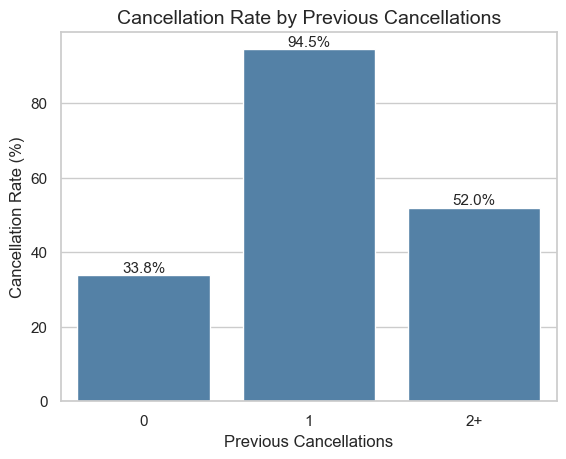

In [60]:
# 4.2.2.1 Previous Cancellation vs Cancellation

df['prev_cancel_group'] = np.where(
    df['previous_cancellations'] >= 2,
    '2+',
    df['previous_cancellations'].astype(str)
)

cancel_rate = (
    df.groupby('prev_cancel_group', as_index=False)['is_canceled']
      .mean()
)

cancel_rate['is_canceled'] *= 100

ax = sns.barplot(
    data=cancel_rate,
    x='prev_cancel_group',
    y='is_canceled',
    color='steelblue'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.xlabel('Previous Cancellations')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Previous Cancellations')
plt.show()

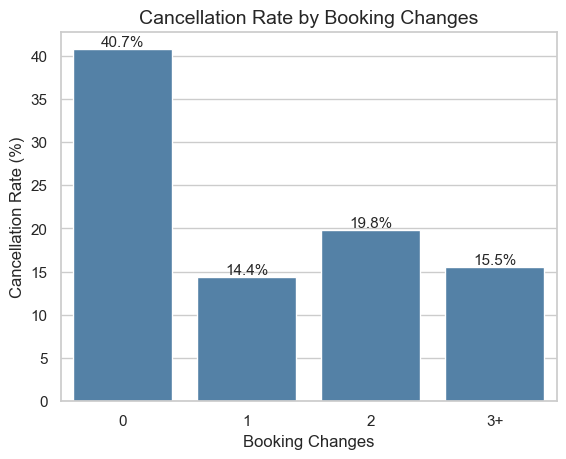

In [62]:
# 4.2.2.2 Booking Changes vs Cancellation

df['booking_changes'] = np.where(
    df['booking_changes'] >= 3,
    '3+',
    df['booking_changes'].astype(str)
)

cancel_rate = (
    df.groupby('booking_changes', as_index=False)['is_canceled']
      .mean()
)

cancel_rate['is_canceled'] *= 100

ax = sns.barplot(
    data=cancel_rate,
    x='booking_changes',
    y='is_canceled',
    color='steelblue'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.xlabel('Booking Changes')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Booking Changes')
plt.show()

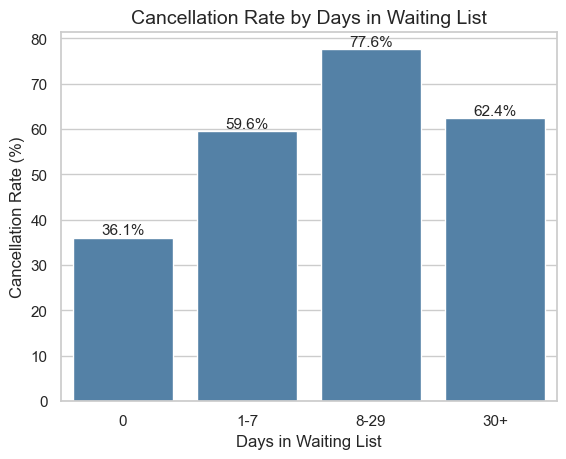

In [63]:
# 4.2.2.3 Days in Waiting List vs Cancellation

df['waiting_list_group'] = pd.cut(
    df['days_in_waiting_list'],
    bins=[-1, 0, 7, 29, float('inf')],
    labels=['0', '1-7', '8-29', '30+']
)

cancel_rate = (
    df.groupby('waiting_list_group', as_index=False)['is_canceled']
      .mean()
)

cancel_rate['is_canceled'] *= 100

ax = sns.barplot(
    data=cancel_rate,
    x='waiting_list_group',
    y='is_canceled',
    color='steelblue'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.xlabel('Days in Waiting List')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Days in Waiting List')
plt.show()

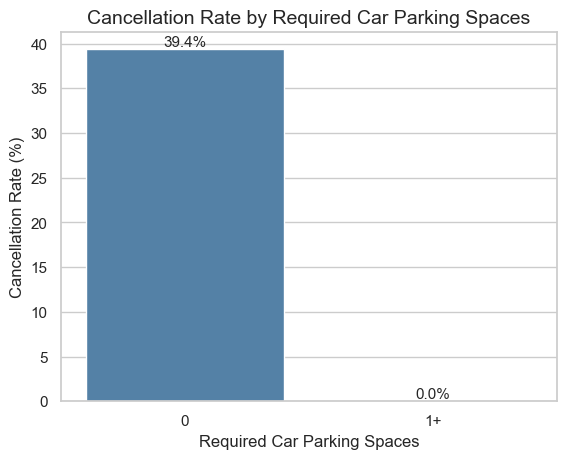

In [64]:
# 4.2.2.4 Required Car Parking Spaces vs Cancellation

df['required_car_parking_spaces'] = np.where(
    df['required_car_parking_spaces'] >= 1,
    '1+',
    df['required_car_parking_spaces'].astype(str)
)

cancel_rate = (
    df.groupby('required_car_parking_spaces', as_index=False)['is_canceled']
      .mean()
)

cancel_rate['is_canceled'] *= 100

ax = sns.barplot(
    data=cancel_rate,
    x='required_car_parking_spaces',
    y='is_canceled',
    color='steelblue'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.xlabel('Required Car Parking Spaces')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Required Car Parking Spaces')
plt.show()

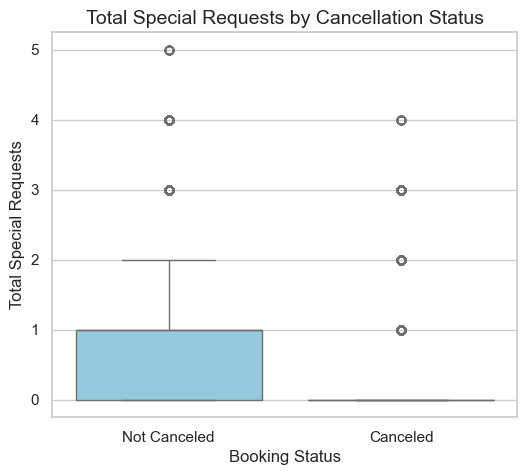

In [65]:
# 4.2.2.5 Total of Special Requests vs Cancellation

df_plot = df.copy()
df_plot['is_canceled'] = df_plot['is_canceled'].map({
    0: 'Not Canceled',
    1: 'Canceled'
})

plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_plot,
    x='is_canceled',
    y='total_of_special_requests',
    color='skyblue'
)

plt.title('Total Special Requests by Cancellation Status')
plt.xlabel('Booking Status')
plt.ylabel('Total Special Requests')

plt.show()

In [66]:
df.groupby('required_car_parking_spaces').agg(
    total=('is_canceled', 'count'),
    canceled=('is_canceled', 'sum'),
    cancel_rate=('is_canceled', 'mean')
)

,total,canceled,cancel_rate
required_car_parking_spaces,,,
0,78070,30731,0.393634
1+,5151,0,0.000000


**Overview:**
1. Customers with 1 previous cancellation have the highest cancellation rate (94.3%), indicating that customers who have canceled before are much more likely to cancel again. Although the cancellation rate drops to 52.0% for customers with 2 or more previous cancellations, it is still considerably higher than for those with no history of cancellations.
2. Bookings with no changes have the highest cancellation rate (40.6%). In contrast, bookings that have been modified at least once show much lower cancellation rates (14.4%–19.7%), suggesting that customers who update their reservations are more likely to follow through with their stay.
3. Bookings with longer waiting times tend to have higher cancellation rates. The highest rate is observed for bookings waiting 8–29 days (77.6%).
4. Bookings without parking requirements had a cancellation rate of 39.3%. However, No cancellations were observed among bookings that requested at least one parking space. This indicates that every customer that require parkings are less likely to cancel their reservations.
5. Most canceled bookings have no special requests. The distribution for canceled bookings is heavily concentrated at zero, indicating that customers who do not request additional services are more likely to cancel their reservations.

## **Section 5. Data Preparation**

### **5.1 Initialization**

In [17]:
# Define feature and target


### **5.2 Constructing `Training` and `Testing` Data (from `Seen` Dataset)**

In [18]:
# split into train and test

# reset index

# print x_train, y_train shape

### **5.3 Handling Imbalanced Data (jika relevan)**

> 🎯 *Tujuan:* Menangani ketimpangan proporsi kelas target supaya model tidak bias ke kelas mayoritas.

> 📌 Cek proporsi kelas target di Section 5.1. Kalau timpang (misal 90:10), pertimbangkan strategi seperti class_weight, SMOTE, atau undersampling — **tapi ingat, teknik resampling hanya boleh diterapkan pada data training**, tidak pernah pada data testing/unseen, supaya evaluasi tetap realistis.

### **5.4 Data Transformation (Feature Engineering)**

> 🎯 *Tujuan:* Melakukan encoding, scaling, atau transformasi lain agar data sesuai kebutuhan algoritma yang dipakai.

### **5.5 Feature Selection**


## **Section 6. Model Development**

### **6.1 Initialization**

### **6.2 Developing the Model Pipeline**

> 📌 Gunakan `Pipeline`/`ColumnTransformer` dari scikit-learn supaya seluruh langkah preprocessing (imputasi, encoding, scaling) ikut ter-*fit* hanya pada data training di setiap fold — ini mencegah data leakage antara fold CV.

### **6.3 Model Benchmarking (Comparing model base performance)**

### **6.4 Hyperparameter Tunning**


### **6.5 Best Model Evaluation**
- Evaluate model on data testing
- Confusion Matrix / Threshold Analysis (Classification) atau Residual Analysis (Regression)


### **6.6 Model Explanation and Interpretation**

#### **6.6.1 How model works**


#### **6.6.2 Model Explanation with SHAP**

## **Section 7. Model Deployment**


### **7.1 Export Model (joblib/pickle)**

### **7.2 Deployment Checklist**
- Versi library yang digunakan
- Format input yang diharapkan model
- Cara memuat ulang pipeline
.

## **Section 8. Conclusion and Recommendation**

### **8.1 Conclusion**
- Conclusion (Model)
- Conclusion (Business)


### **8.2 Recommendation**
- Recommendation (Model)
- Recommendation (Business)